# Sign Language Training - Optimized Program

此版本是可執行程式模板（非純說明）：
- GRU/LSTM 單一入口切換
- **自動偵測訓練模式**（fresh / resume / expand 增量訓練）
- StratifiedShuffleSplit 分層切分
- 資料清洗（NaN/Inf 移除）
- 資料增強（scale / translation / noise / time-warp 5×）
- LR scheduler + EarlyStopping + ModelCheckpoint
- Per-class 評估 + 混淆矩陣
- TFLite 轉換與測試

## 執行順序與前置條件

建議由上到下執行：
1. 第 2 格：載入套件與全域參數
2. 第 3 格：資料讀取 → 清洗 → 模式偵測 → 分割 → 資料增強
3. 第 4 格：建立/載入模型並訓練（自動偵測 fresh/resume/expand）
4. 第 5 格：評估、匯出 SavedModel/TFLite、快速推論測試
5. 第 6 格：可選的 5-fold 交叉驗證

執行前請確認：
- 目前工作目錄是 `cv_hands`
- 已安裝 TensorFlow、scikit-learn、seaborn
- `Words-Dataset` 與 `Word-Label` 資料夾存在

**訓練模式自動偵測**：
- 若 `model/keypoint_classifier/keypoint_sequence_classifier.keras` 不存在 → `fresh` 從零訓練
- 若存在且類別數相同 → `resume` 繼續微調
- 若存在且類別數增加 → `expand` 增量學習（新類別 + replay 舊類別）

In [1]:
import glob
import platform
import random
import subprocess
import sys
from pathlib import Path

def ensure_package(import_name, pip_name=None):
    try:
        return __import__(import_name)
    except ModuleNotFoundError:
        pkg = pip_name or import_name
        print(f"Installing missing package: {pkg}")
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg])
        return __import__(import_name)

np = ensure_package('numpy')
tf = ensure_package('tensorflow')
matplotlib = ensure_package('matplotlib')
plt = __import__('matplotlib.pyplot', fromlist=['pyplot'])
sns = ensure_package('seaborn')

sklearn_model_selection = __import__('sklearn.model_selection', fromlist=['train_test_split'])
sklearn_metrics = __import__('sklearn.metrics', fromlist=['classification_report', 'confusion_matrix'])
train_test_split = sklearn_model_selection.train_test_split
classification_report = sklearn_metrics.classification_report
confusion_matrix = sklearn_metrics.confusion_matrix

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / 'Words-Dataset'
LABEL_CSV = PROJECT_ROOT / 'Word-Label' / 'keypoint_sequence_classifier_label.csv'
SAVE_DIR = PROJECT_ROOT / 'model' / 'keypoint_classifier'
SAVE_DIR.mkdir(parents=True, exist_ok=True)

MODEL_TYPE = 'GRU'  # or 'LSTM'
RANDOM_SEED = 42
SEQUENCE_LENGTH = 25
FEATURES_PER_FRAME = 80
TRAIN_SIZE = 0.75
BATCH_SIZE = 256
EPOCHS = 1000
USE_STREAMING = False  # True: tf.data 串流, False: 直接 numpy 訓練

# ── 無需新增資料的穩定化設定 ──
ENABLE_RELATIVE_COORD_NORMALIZATION = True   # 以手腕為原點 + 尺度正規化
ENABLE_SYNTHETIC_NONE_CLASS = True           # 以現有資料合成背景/休息樣本
SYNTHETIC_NONE_RATIO = 0.25                  # 以訓練集比例生成 None 樣本數
NONE_CLASS_WEIGHT_FACTOR = 0.35              # 降低 None 類權重，避免壓過正常詞彙
AUG_TIME_WARP_MAX_SHIFT = 4                  # time-warp 最大平移幀數
AUG_LEADING_NOISE_RATIO = 0.25               # 前導雜訊佔序列比例

# ── 增量訓練設定 ──
MODEL_SAVE_PATH = SAVE_DIR / 'keypoint_sequence_classifier.keras'
BEST_WEIGHTS_PATH = SAVE_DIR / 'keypoint_sequence_classifier.best.weights.h5'
SAVED_MODEL_DIR = SAVE_DIR / 'keypoint_sequence_classifier_savedmodel'
TFLITE_SAVE_PATH = SAVE_DIR / 'keypoint_sequence_classifier.tflite'
REPLAY_PER_OLD_CLASS = 20   # expand 模式中每個舊類別的 replay 樣本數
WARMUP_EPOCHS = 5           # expand 模式的分類頭預熱輪數

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print('TensorFlow:', tf.__version__)
print('Keras:', getattr(tf.keras, '__version__', 'unknown'))
print('Data dir exists:', DATA_DIR.exists())
print('Label file exists:', LABEL_CSV.exists())
print('Model save path:', MODEL_SAVE_PATH)
print('Best weights path:', BEST_WEIGHTS_PATH)
print('Existing model found:', MODEL_SAVE_PATH.exists())
print('USE_STREAMING:', USE_STREAMING)
print('ENABLE_RELATIVE_COORD_NORMALIZATION:', ENABLE_RELATIVE_COORD_NORMALIZATION)
print('ENABLE_SYNTHETIC_NONE_CLASS:', ENABLE_SYNTHETIC_NONE_CLASS)
print('SYNTHETIC_NONE_RATIO:', SYNTHETIC_NONE_RATIO)

TensorFlow: 2.10.1
Keras: 2.10.0
Data dir exists: True
Label file exists: True
Model save path: c:\GitHub\FYP-SignLanguage\cv_hands\model\keypoint_classifier\keypoint_sequence_classifier.keras
Best weights path: c:\GitHub\FYP-SignLanguage\cv_hands\model\keypoint_classifier\keypoint_sequence_classifier.best.weights.h5
Existing model found: True
USE_STREAMING: False
ENABLE_RELATIVE_COORD_NORMALIZATION: True
ENABLE_SYNTHETIC_NONE_CLASS: True
SYNTHETIC_NONE_RATIO: 0.25


## 第 3 格在做什麼？（資料處理 + 模式偵測）

這一格會完成資料前處理主流程：
- 啟用 GPU 記憶體成長模式（若有 GPU）
- 載入標籤與序列資料
- `sanitize_dataset()`：移除 NaN/Inf 與超範圍標籤
- 偵測訓練模式（fresh / resume / expand）
- expand 模式下：`build_incremental_subset()` 組合新類別 + 舊類別 replay
- 使用 `StratifiedShuffleSplit` 做分層切分（失敗時 fallback 隨機切分）
- 對訓練集做資料增強（scale / translation / noise / time-warp 5×）

如果這格報錯，通常是：
- `FEATURES_PER_FRAME` 與資料實際維度不一致
- 某些 CSV 檔案欄位數異常
- 標籤檔與資料集不對應

In [2]:
import csv
import os
import re


# ══════════════════════════════════════════════
#  GPU / 標籤 / 資料載入
# ══════════════════════════════════════════════

def setup_gpu():
    """設定 CUDA/cuDNN DLL 路徑並啟用 GPU memory growth。"""
    CUDA_BIN = Path(r"C:/Program Files/NVIDIA GPU Computing Toolkit/CUDA/v11.5/bin")
    CUDNN_BIN_CANDIDATES = [
        Path.cwd() / "third_party" / "cudnn-8.9.7-cuda11" / "bin",
        Path.cwd() / "cv_hands" / "third_party" / "cudnn-8.9.7-cuda11" / "bin",
    ]

    dll_paths = []
    if CUDA_BIN.exists():
        dll_paths.append(str(CUDA_BIN))
    for candidate in CUDNN_BIN_CANDIDATES:
        if candidate.exists():
            dll_paths.append(str(candidate))
            break
    if dll_paths:
        os.environ["PATH"] = ";".join(dll_paths + [os.environ.get("PATH", "")])
        print("DLL search paths:", dll_paths)

    gpus = tf.config.list_physical_devices('GPU')
    if not gpus:
        print('No GPU detected, using CPU.')
        return
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print('GPU ready:', gpus)


def load_labels(path):
    """讀取標籤 CSV（自動處理 UTF-8 BOM）。"""
    with open(path, 'r', encoding='utf-8-sig') as f:
        reader = csv.reader(f)
        return [row[0] for row in reader if row]


def infer_label_from_filename(file_path):
    """從檔名推斷類別，例如 001_sequence.csv -> 1。"""
    stem = Path(file_path).stem
    match = re.match(r'^(\d+)_sequence$', stem)
    if not match:
        return None
    return int(match.group(1))


def load_dataset(data_dir, seq_len, feat_dim):
    files = sorted(glob.glob(str(data_dir / '*_sequence.csv')))
    if not files:
        raise FileNotFoundError('No *_sequence.csv files found.')

    X_list, y_list = [], []
    expected_cols = 1 + seq_len * feat_dim

    for file_path in files:
        arr = np.loadtxt(file_path, delimiter=',', dtype=np.float32)
        arr = np.atleast_2d(arr)
        if arr.shape[1] != expected_cols:
            raise ValueError(f'Column mismatch in {file_path}: {arr.shape[1]} != {expected_cols}')

        inferred = infer_label_from_filename(file_path)
        if inferred is not None:
            y = np.full((arr.shape[0],), inferred, dtype=np.int32)
        else:
            y = arr[:, 0].astype(np.int32)
            print(f'Warning: fallback to first-column labels for {Path(file_path).name}')

        X = arr[:, 1:].reshape(-1, seq_len, feat_dim).astype(np.float32)
        X_list.append(X)
        y_list.append(y)

    X_dataset = np.concatenate(X_list, axis=0)
    y_dataset = np.concatenate(y_list, axis=0)
    return X_dataset, y_dataset


def normalize_labels(y, num_classes):
    """支援 1-based 或 0-based，最終統一 0-based。"""
    if y.min() == 1:
        y = y - 1
    if y.min() < 0 or y.max() >= num_classes:
        raise ValueError(
            f'Label out of range after normalization: min={y.min()}, max={y.max()}, classes={num_classes}. '
            '請確認檔名是否為 001_sequence.csv 這種格式，或檢查標籤檔與資料集是否一致。'
        )
    return y.astype(np.int32)


# ══════════════════════════════════════════════
#  資料清洗 / 增強 / 權重
# ══════════════════════════════════════════════

def sanitize_dataset(X, y, num_classes):
    """移除 NaN/Inf 與超範圍標籤的樣本。"""
    finite_mask = np.isfinite(X).all(axis=(1, 2))
    removed_non_finite = int((~finite_mask).sum())
    if removed_non_finite > 0:
        print(f'Removed non-finite samples: {removed_non_finite}')
    X, y = X[finite_mask], y[finite_mask]
    X = np.nan_to_num(X, nan=0.0, posinf=1e3, neginf=-1e3).astype('float32')

    valid_label_mask = (y >= 0) & (y < num_classes)
    removed_invalid = int((~valid_label_mask).sum())
    if removed_invalid > 0:
        print(f'Removed invalid-label samples: {removed_invalid}')
    X, y = X[valid_label_mask], y[valid_label_mask]
    return X, y


def normalize_relative_coordinates(X, anchor_idx=0, eps=1e-6):
    """以 anchor 關鍵點為原點，並做每筆樣本尺度正規化。"""
    N, T, F = X.shape
    if F % 2 != 0:
        raise ValueError(f'FEATURES_PER_FRAME={F} must be even for (x,y) pairs.')

    P = X.reshape(N, T, F // 2, 2).astype(np.float32)
    anchor = P[:, :, anchor_idx:anchor_idx + 1, :]
    P_rel = P - anchor

    dist = np.linalg.norm(P_rel, axis=-1)  # (N, T, K)
    scale = np.mean(dist, axis=(1, 2), keepdims=True).astype(np.float32)  # (N, 1, 1)
    scale = np.maximum(scale, np.float32(eps))
    P_rel = P_rel / scale[..., None]
    return P_rel.reshape(N, T, F).astype(np.float32)


def synthesize_none_samples(X_ref, n_samples, noise_std=0.003, hold_prob=0.7, seed=42):
    """從既有序列合成背景/休息窗口，不需額外蒐集資料。"""
    rng = np.random.default_rng(seed)
    n_samples = int(max(0, n_samples))
    if n_samples == 0:
        return np.empty((0,) + X_ref.shape[1:], dtype=np.float32)

    picked = rng.integers(0, X_ref.shape[0], size=n_samples)
    X_base = X_ref[picked].copy().astype(np.float32)

    # 先做接近靜止的基底
    X_none = np.zeros_like(X_base, dtype=np.float32)

    # 混入極小雜訊，避免全零過於理想化
    X_none += rng.normal(0.0, noise_std, size=X_none.shape).astype(np.float32)

    # 部分樣本用 hold-last-frame 模擬停留/過渡
    hold_mask = rng.random(n_samples) < hold_prob
    if np.any(hold_mask):
        X_hold = X_base[hold_mask]
        X_hold[:, 1:, :] = X_hold[:, :1, :]
        X_none[hold_mask] = X_hold

    return X_none.astype(np.float32)


def augment_sequence(X, y):
    """資料增強（不新增外部資料）：scale / translation / noise / time-warp / leading-noise。"""
    scale = np.random.uniform(0.85, 1.15, size=(X.shape[0], 1, X.shape[2])).astype(np.float32)
    X_scaled = X * scale

    if ENABLE_RELATIVE_COORD_NORMALIZATION:
        X_shifted = X.copy()
    else:
        shift = np.random.uniform(-0.08, 0.08, size=(X.shape[0], 1, X.shape[2])).astype(np.float32)
        X_shifted = X + shift

    noise = np.random.normal(0, 0.015, size=X.shape).astype(np.float32)
    X_noise = X + noise

    shifts = np.random.randint(1, AUG_TIME_WARP_MAX_SHIFT + 1, size=X.shape[0])
    X_warp = np.empty_like(X)
    for i, s in enumerate(shifts):
        direction = -1 if np.random.rand() < 0.5 else 1
        X_warp[i] = np.roll(X[i], shift=direction * s, axis=0)

    lead_k = max(1, int(X.shape[1] * AUG_LEADING_NOISE_RATIO))
    X_lead = X.copy().astype(np.float32)
    lead_noise = np.random.normal(0, 0.02, size=(X.shape[0], lead_k, X.shape[2])).astype(np.float32)
    X_lead[:, :lead_k, :] = lead_noise

    X_aug = np.concatenate([X, X_scaled, X_shifted, X_noise, X_warp, X_lead], axis=0).astype(np.float32)
    y_aug = np.concatenate([y, y, y, y, y, y], axis=0).astype(np.int32)
    return X_aug, y_aug


def make_class_weight(y):
    """根據各類別樣本數計算反比權重，緩解類別不平衡。"""
    classes = np.unique(y)
    total = len(y)
    weights = {}
    for c in classes:
        count = int((y == c).sum())
        weights[int(c)] = total / (len(classes) * count) if count > 0 else 1.0
    return weights


def safe_split(X, y, train_size=0.75, random_state=42):
    """使用 StratifiedShuffleSplit，失敗時 fallback 為隨機 split。"""
    from sklearn.model_selection import StratifiedShuffleSplit

    try:
        sss = StratifiedShuffleSplit(n_splits=1, train_size=train_size, random_state=random_state)
        train_idx, test_idx = next(sss.split(X, y))
        return X[train_idx], X[test_idx], y[train_idx], y[test_idx]
    except Exception:
        print('StratifiedShuffleSplit failed, fallback to random split.')
        return train_test_split(X, y, train_size=train_size, random_state=random_state)


# ══════════════════════════════════════════════
#  增量訓練工具（expand 模式）
# ══════════════════════════════════════════════

def copy_backbone_weights(old_model, new_model):
    """將舊模型的骨幹層權重複製到新模型（跳過 classifier 層）。"""
    copied = []
    for layer in new_model.layers:
        if layer.name in ('classifier', 'predictions'):
            continue
        try:
            old_layer = old_model.get_layer(layer.name)
            layer.set_weights(old_layer.get_weights())
            copied.append(layer.name)
        except Exception:
            pass
    print('Copied backbone layers:', copied)


def _find_output_dense_layer(model, preferred_names=('classifier', 'predictions')):
    """優先用名稱找輸出層；找不到時回退為最後一個 Dense 層。"""
    for name in preferred_names:
        try:
            return model.get_layer(name)
        except Exception:
            pass

    dense_layers = [layer for layer in model.layers if isinstance(layer, tf.keras.layers.Dense)]
    if dense_layers:
        return dense_layers[-1]

    raise ValueError(
        f'Could not locate an output Dense layer. Existing layers: {[layer.name for layer in model.layers]}'
    )


def expand_classifier_weights(old_model, new_model, classifier_name='classifier'):
    """將舊模型的分類頭權重擴展到新模型（新類別用隨機初始化）。"""
    old_cls = _find_output_dense_layer(old_model, preferred_names=(classifier_name, 'predictions'))
    new_cls = _find_output_dense_layer(new_model, preferred_names=(classifier_name, 'predictions'))
    old_w, old_b = old_cls.get_weights()
    new_w, new_b = new_cls.get_weights()

    old_in_dim = old_w.shape[0]
    new_in_dim = new_w.shape[0]
    old_classes = old_w.shape[1]
    new_classes = new_w.shape[1]
    if new_classes < old_classes:
        raise ValueError(f'New classes ({new_classes}) < old classes ({old_classes}), cannot expand head.')

    copy_in_dim = min(old_in_dim, new_in_dim)
    copy_classes = min(old_classes, new_classes)

    new_w[:copy_in_dim, :copy_classes] = old_w[:copy_in_dim, :copy_classes]
    new_b[:copy_classes] = old_b[:copy_classes]
    new_cls.set_weights([new_w, new_b])
    print(
        f'Expanded classifier: {old_classes} -> {new_classes} '
        f'(old head: {old_cls.name}, new head: {new_cls.name}, '
        f'copied in_dim: {copy_in_dim}/{old_in_dim}->{new_in_dim}, '
        f'copied classes: {copy_classes})'
    )


def build_incremental_subset(X_train, y_train, old_num_classes, replay_per_old_class, seed=42):
    """組合新類別全量 + 每個舊類別的 replay 子集。"""
    rng = np.random.default_rng(seed)

    new_mask = y_train >= old_num_classes
    idx_new = np.where(new_mask)[0]

    idx_replay = []
    for c in range(old_num_classes):
        idx_c = np.where(y_train == c)[0]
        if len(idx_c) == 0:
            continue
        k = min(replay_per_old_class, len(idx_c))
        picked = rng.choice(idx_c, size=k, replace=False)
        idx_replay.extend(picked.tolist())
    idx_replay = np.array(idx_replay, dtype=np.int64)

    idx_final = np.concatenate([idx_new, idx_replay]) if len(idx_new) > 0 else idx_replay
    if len(idx_final) == 0:
        raise ValueError('Incremental subset is empty. Please check labels/data.')

    rng.shuffle(idx_final)
    summary = {
        'new_samples': int(len(idx_new)),
        'replay_samples': int(len(idx_replay)),
        'total_samples': int(len(idx_final)),
    }
    return X_train[idx_final], y_train[idx_final], summary


def try_load_existing_model(model_save_path):
    """嘗試以多種格式載入既有模型，處理跨機器/跨 TF 版本相容問題。"""
    model_path = Path(model_save_path)
    candidates = [model_path]

    # 常見備援路徑
    stem = model_path.with_suffix('')
    candidates.extend([
        stem.with_suffix('.h5'),
        stem.with_suffix('.hdf5'),
        Path(str(stem) + '_savedmodel'),
    ])
    if 'SAVED_MODEL_DIR' in globals():
        candidates.append(Path(SAVED_MODEL_DIR))

    # 去重但保留順序
    unique_candidates = []
    seen = set()
    for p in candidates:
        p = Path(p)
        key = str(p.resolve()) if p.exists() else str(p)
        if key in seen:
            continue
        seen.add(key)
        unique_candidates.append(p)

    errors = []
    for p in unique_candidates:
        if not p.exists():
            continue
        try:
            m = tf.keras.models.load_model(str(p), compile=False)
            print(f'Loaded existing model from: {p}')
            return m, p
        except Exception as e:
            errors.append(f'{p}: {type(e).__name__}: {e}')

    if errors:
        print('Existing model detected but loading failed on this machine:')
        for msg in errors:
            print(' -', msg)
        print('Likely cause: TensorFlow/Keras version mismatch or incompatible model format.')
    return None, None


def detect_train_mode(model_save_path, num_classes):
    """偵測訓練模式：fresh / resume / expand。"""
    existing_model, loaded_from = try_load_existing_model(model_save_path)
    if existing_model is None:
        print('No compatible existing model found → TRAIN_MODE = fresh')
        return 'fresh', None, 0

    old_num_classes = int(existing_model.output_shape[-1])
    print(f'Existing model classes={old_num_classes} (from {loaded_from})')

    if old_num_classes == num_classes:
        print(f'Class count unchanged ({num_classes}) → TRAIN_MODE = resume')
        return 'resume', existing_model, old_num_classes
    if old_num_classes < num_classes:
        print(f'Class count expanded ({old_num_classes} → {num_classes}) → TRAIN_MODE = expand')
        return 'expand', existing_model, old_num_classes

    raise ValueError(
        f'Existing model classes ({old_num_classes}) > current labels ({num_classes}). '
        'Please verify label file / model compatibility.'
    )


# ══════════════════════════════════════════════
#  執行：載入 → 清洗 → 偵測模式 → 分割 → 增強
# ══════════════════════════════════════════════

setup_gpu()
labels = load_labels(LABEL_CSV)
if ENABLE_SYNTHETIC_NONE_CLASS and '__NONE__' not in labels:
    labels.append('__NONE__')
NUM_CLASSES = len(labels)
NONE_CLASS_INDEX = labels.index('__NONE__') if '__NONE__' in labels else None

X_dataset, y_dataset = load_dataset(DATA_DIR, SEQUENCE_LENGTH, FEATURES_PER_FRAME)
y_dataset = normalize_labels(y_dataset, NUM_CLASSES)
X_dataset, y_dataset = sanitize_dataset(X_dataset, y_dataset, NUM_CLASSES)
if ENABLE_RELATIVE_COORD_NORMALIZATION:
    X_dataset = normalize_relative_coordinates(X_dataset, anchor_idx=0)
    print('Applied relative-coordinate normalization (anchor_idx=0).')

# 偵測訓練模式
TRAIN_MODE, existing_model, old_num_classes = detect_train_mode(MODEL_SAVE_PATH, NUM_CLASSES)

# 分割
X_train_full, X_test, y_train_full, y_test = safe_split(
    X_dataset, y_dataset, train_size=TRAIN_SIZE, random_state=RANDOM_SEED
)

# 使用現有資料合成 None/背景類（只加入訓練集）
if ENABLE_SYNTHETIC_NONE_CLASS and NONE_CLASS_INDEX is not None:
    synth_n = int(len(X_train_full) * SYNTHETIC_NONE_RATIO)
    X_none = synthesize_none_samples(X_train_full, synth_n, seed=RANDOM_SEED)
    y_none = np.full((len(X_none),), NONE_CLASS_INDEX, dtype=np.int32)
    X_train_full = np.concatenate([X_train_full, X_none], axis=0)
    y_train_full = np.concatenate([y_train_full, y_none], axis=0)
    print(f'Injected synthetic None samples: {len(X_none)} (class idx={NONE_CLASS_INDEX})')

# expand 模式：只取新類別 + 舊類別 replay
if TRAIN_MODE == 'expand':
    X_train, y_train, inc_summary = build_incremental_subset(
        X_train_full, y_train_full, old_num_classes, REPLAY_PER_OLD_CLASS, seed=RANDOM_SEED
    )
    print('Incremental subset summary:', inc_summary)
else:
    X_train, y_train = X_train_full, y_train_full

# 資料增強（所有模式都做）
X_train, y_train = augment_sequence(X_train, y_train)
class_weight = make_class_weight(y_train)
if ENABLE_SYNTHETIC_NONE_CLASS and NONE_CLASS_INDEX in class_weight:
    class_weight[NONE_CLASS_INDEX] *= NONE_CLASS_WEIGHT_FACTOR
    print(f'Adjusted None class weight by factor={NONE_CLASS_WEIGHT_FACTOR:.3f}')

print()
print('TRAIN_MODE:', TRAIN_MODE)
print('X_train:', X_train.shape, 'y_train:', y_train.shape)
print('X_test :', X_test.shape, 'y_test :', y_test.shape)
print('num_classes:', NUM_CLASSES)
if NONE_CLASS_INDEX is not None:
    print('None class index:', NONE_CLASS_INDEX)
print('y range after normalize:', int(y_dataset.min()), 'to', int(y_dataset.max()))
print('class_weight keys (first 10):', sorted(class_weight.keys())[:10], '... total', len(class_weight))

DLL search paths: ['C:\\Program Files\\NVIDIA GPU Computing Toolkit\\CUDA\\v11.5\\bin', 'c:\\GitHub\\FYP-SignLanguage\\cv_hands\\third_party\\cudnn-8.9.7-cuda11\\bin']
GPU ready: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Applied relative-coordinate normalization (anchor_idx=0).
Loaded existing model from: c:\GitHub\FYP-SignLanguage\cv_hands\model\keypoint_classifier\keypoint_sequence_classifier.keras
Existing model classes=156 (from c:\GitHub\FYP-SignLanguage\cv_hands\model\keypoint_classifier\keypoint_sequence_classifier.keras)
Class count expanded (156 → 157) → TRAIN_MODE = expand
Injected synthetic None samples: 43278 (class idx=156)
Incremental subset summary: {'new_samples': 43278, 'replay_samples': 3120, 'total_samples': 46398}
Adjusted None class weight by factor=0.350

TRAIN_MODE: expand
X_train: (278388, 25, 80) y_train: (278388,)
X_test : (57704, 25, 80) y_test : (57704,)
num_classes: 157
None class index: 156
y range after normalize: 0 to 155
class_w

## 第 4 格在做什麼？（建模與訓練）

這一格會依偵測到的 `TRAIN_MODE` 採取不同策略：

| 模式 | 行為 |
|------|------|
| **fresh** | 建新模型，從零開始訓練 |
| **resume** | 載入已存模型，繼續微調 |
| **expand** | 建新模型（擴展分類頭），先凍結骨幹 warmup → 再全模型 fine-tune |

所有模式共用：
- Bidirectional RNN + LayerNorm + MultiHeadAttention
- 自訂最佳模型儲存：**先比 `val_accuracy`，同 `val_accuracy` 再比 `val_loss`**
- 以 `tf.data` generator 串流批次，降低大資料搬運造成的 GPU 初始化失敗
- `ReduceLROnPlateau` + `EarlyStopping`
- `class_weight` 緩解不平衡
- GPU 訓練失敗時自動 fallback 到 CPU

你可優先調整：
- `EPOCHS`、`BATCH_SIZE`
- `MODEL_TYPE`（GRU / LSTM）
- `WARMUP_EPOCHS`（expand 模式）
- `REPLAY_PER_OLD_CLASS`（expand 模式中每個舊類別保留多少 replay 樣本）

In [3]:
def build_model(model_type, seq_len, feat_dim, num_classes):
    if model_type.upper() == 'GRU':
        rnn = tf.keras.layers.GRU
    elif model_type.upper() == 'LSTM':
        rnn = tf.keras.layers.LSTM
    else:
        raise ValueError('MODEL_TYPE must be GRU or LSTM')

    reg = tf.keras.regularizers.l2(1e-4)
    inp = tf.keras.Input(shape=(seq_len, feat_dim), name='sequence_input')
    x = tf.keras.layers.Bidirectional(rnn(128, return_sequences=True, kernel_regularizer=reg), name='birnn_1')(inp)
    x = tf.keras.layers.LayerNormalization(name='ln_1')(x)
    x = tf.keras.layers.Bidirectional(rnn(64, return_sequences=True, kernel_regularizer=reg), name='birnn_2')(x)
    x = tf.keras.layers.LayerNormalization(name='ln_2')(x)
    x = tf.keras.layers.MultiHeadAttention(num_heads=2, key_dim=32, name='mha')(x, x)
    x = tf.keras.layers.GlobalAveragePooling1D(name='gap')(x)
    x = tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=reg, name='dense_1')(x)
    x = tf.keras.layers.Dropout(0.3, name='dropout_1')(x)
    out = tf.keras.layers.Dense(num_classes, activation='softmax', name='classifier')(x)
    return tf.keras.Model(inp, out, name=f'{model_type.lower()}_sequence_classifier')


def compile_model(m, lr=1e-3):
    m.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return m


class BestByAccThenLossCheckpoint(tf.keras.callbacks.Callback):
    """優先比較 val_accuracy；若相同則比較 val_loss，改善就儲存 best weights。"""

    def __init__(self, filepath, min_delta_acc=0.0, min_delta_loss=0.0, verbose=1):
        super().__init__()
        self.filepath = str(filepath)
        self.min_delta_acc = float(min_delta_acc)
        self.min_delta_loss = float(min_delta_loss)
        self.verbose = verbose
        self.best_acc = -np.inf
        self.best_loss = np.inf

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        val_acc = logs.get('val_accuracy')
        val_loss = logs.get('val_loss')

        if val_acc is None or val_loss is None:
            return

        improved_acc = val_acc > (self.best_acc + self.min_delta_acc)
        same_acc = abs(val_acc - self.best_acc) <= self.min_delta_acc
        improved_loss = val_loss < (self.best_loss - self.min_delta_loss)

        should_save = improved_acc or (same_acc and improved_loss)

        if should_save:
            prev_acc, prev_loss = self.best_acc, self.best_loss
            self.best_acc = float(val_acc)
            self.best_loss = float(val_loss)
            self.model.save_weights(self.filepath)
            if self.verbose:
                reason = 'val_accuracy improved' if improved_acc else 'val_loss improved under same val_accuracy'
                print(
                    f"\nEpoch {epoch + 1}: {reason}, saved best weights to {self.filepath} "
                    f"(acc: {prev_acc:.4f} -> {self.best_acc:.4f}, loss: {prev_loss:.6f} -> {self.best_loss:.6f})"
                )


def create_model_for_mode(train_mode, existing_model_ref):
    if train_mode == 'fresh':
        model_local = build_model(MODEL_TYPE, SEQUENCE_LENGTH, FEATURES_PER_FRAME, NUM_CLASSES)
        print('Built new model from scratch.')
    elif train_mode == 'resume':
        if existing_model_ref is not None:
            model_local = existing_model_ref
            print('Reused existing_model for resume training.')
        else:
            model_local, loaded_from = try_load_existing_model(MODEL_SAVE_PATH)
            if model_local is None:
                raise RuntimeError('TRAIN_MODE=resume but no compatible model could be loaded.')
            print(f'Loaded existing model for resume training from: {loaded_from}')
    else:  # expand
        model_local = build_model(MODEL_TYPE, SEQUENCE_LENGTH, FEATURES_PER_FRAME, NUM_CLASSES)
        copy_backbone_weights(existing_model_ref, model_local)
        expand_classifier_weights(existing_model_ref, model_local, classifier_name='classifier')
        print('Built expanded model with warm-started backbone.')
    return model_local


def make_batched_dataset(X, y, batch_size, shuffle, seed):
    """用 generator 串流批次，避免一次把整包陣列常量化搬到 GPU。"""
    steps = int(np.ceil(len(X) / batch_size))

    def _generator():
        indices = np.arange(len(X), dtype=np.int32)
        if shuffle:
            np.random.default_rng(seed + np.random.randint(0, 1_000_000)).shuffle(indices)

        for start in range(0, len(indices), batch_size):
            batch_idx = indices[start:start + batch_size]
            yield X[batch_idx].astype(np.float32), y[batch_idx].astype(np.int32)

    output_signature = (
        tf.TensorSpec(shape=(None, SEQUENCE_LENGTH, FEATURES_PER_FRAME), dtype=tf.float32),
        tf.TensorSpec(shape=(None,), dtype=tf.int32),
    )

    dataset = tf.data.Dataset.from_generator(_generator, output_signature=output_signature)
    dataset = dataset.repeat().prefetch(tf.data.AUTOTUNE)
    return dataset, steps


# ── 建立 / 載入模型 ──
model = create_model_for_mode(TRAIN_MODE, existing_model)
model.summary()

# ── Callbacks ──
callbacks = [
    BestByAccThenLossCheckpoint(
        BEST_WEIGHTS_PATH,
        min_delta_acc=0.0,
        min_delta_loss=1e-6,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', mode='min', patience=10, min_delta=1e-8, restore_best_weights=True
    ),
    tf.keras.callbacks.TerminateOnNaN()
]

# ── 訓練 ──
def run_training(model, X_train, y_train, X_test, y_test, class_weight,
                 train_mode, epochs, batch_size, warmup_epochs, callbacks,
                 existing_model_ref):
    """根據 train_mode 執行訓練；GPU 失敗時先用較小 batch 重試，再 fallback CPU。"""

    def _fit(m, ep, bs, cbs, cw, use_streaming, verbose=1):
        if use_streaming:
            train_ds, train_steps = make_batched_dataset(X_train, y_train, bs, shuffle=True, seed=RANDOM_SEED)
            val_ds, val_steps = make_batched_dataset(X_test, y_test, bs, shuffle=False, seed=RANDOM_SEED)
            return m.fit(
                train_ds,
                validation_data=val_ds,
                epochs=ep,
                steps_per_epoch=train_steps,
                validation_steps=val_steps,
                callbacks=cbs,
                class_weight=cw,
                verbose=verbose
            )

        # 非串流模式：直接使用 numpy arrays
        return m.fit(
            X_train.astype(np.float32),
            y_train.astype(np.int32),
            validation_data=(X_test.astype(np.float32), y_test.astype(np.int32)),
            epochs=ep,
            batch_size=bs,
            callbacks=cbs,
            class_weight=cw,
            verbose=verbose
        )

    def _train_once(m, bs, use_streaming):
        if train_mode == 'expand':
            for layer in m.layers:
                layer.trainable = (layer.name == 'classifier')
            compile_model(m, lr=1e-3)
            print(f'Phase 1 (expand): classifier warm-up for {warmup_epochs} epochs, batch_size={bs}')
            _fit(m, warmup_epochs, bs, callbacks, class_weight, use_streaming)

            for layer in m.layers:
                layer.trainable = True
            compile_model(m, lr=1e-4)
            print(f'Phase 2 (expand): full fine-tune for {epochs} epochs, batch_size={bs}')
            return _fit(m, epochs, bs, callbacks, class_weight, use_streaming)

        lr = 1e-3 if train_mode == 'fresh' else 3e-4
        compile_model(m, lr=lr)
        input_mode = 'streaming(tf.data)' if use_streaming else 'non-streaming(numpy)'
        print(f'Training ({train_mode}) for {epochs} epochs, batch_size={bs}, input={input_mode} ...')
        return _fit(m, epochs, bs, callbacks, class_weight, use_streaming)

    primary_streaming = bool(USE_STREAMING)
    try:
        history = _train_once(model, batch_size, primary_streaming)
        return model, history
    except (tf.errors.InternalError, tf.errors.ResourceExhaustedError) as e:
        print(f'\nGPU training failed at batch_size={batch_size}: {e}')

    if not primary_streaming:
        try:
            print('\nRetry on GPU with streaming input pipeline at same batch_size ...')
            tf.keras.backend.clear_session()
            model = create_model_for_mode(train_mode, existing_model_ref)
            history = _train_once(model, batch_size, True)
            print('GPU retry succeeded after switching to streaming input.')
            return model, history
        except (tf.errors.InternalError, tf.errors.ResourceExhaustedError) as stream_e:
            print(f'GPU retry with streaming input failed: {stream_e}')

    retry_bs_list = []
    half_bs = max(8, batch_size // 2)
    retry_bs_list.append(half_bs)
    if half_bs != 8:
        retry_bs_list.append(8)

    retry_streaming = True if not primary_streaming else primary_streaming

    for retry_bs in retry_bs_list:
        try:
            retry_mode = 'streaming(tf.data)' if retry_streaming else 'non-streaming(numpy)'
            print(f'\nRetry on GPU with smaller batch_size={retry_bs}, input={retry_mode} ...')
            tf.keras.backend.clear_session()
            model = create_model_for_mode(train_mode, existing_model_ref)
            history = _train_once(model, retry_bs, retry_streaming)
            print(f'GPU retry succeeded with batch_size={retry_bs}.')
            return model, history
        except (tf.errors.InternalError, tf.errors.ResourceExhaustedError) as retry_e:
            print(f'GPU retry failed at batch_size={retry_bs}: {retry_e}')

    print('\nFallback: rebuild model on CPU.')
    tf.keras.backend.clear_session()
    cpu_bs = 8
    with tf.device('/CPU:0'):
        model = create_model_for_mode(train_mode, existing_model_ref)
        history = _train_once(model, cpu_bs, True)
    print(f'CPU fallback completed with batch_size={cpu_bs}.')
    return model, history


model, history = run_training(
    model, X_train, y_train, X_test, y_test, class_weight,
    TRAIN_MODE, EPOCHS, BATCH_SIZE, WARMUP_EPOCHS, callbacks,
    existing_model
)

# 優先載入驗證最佳權重，確保後續評估/匯出使用最佳版本
if BEST_WEIGHTS_PATH.exists():
    model.load_weights(str(BEST_WEIGHTS_PATH))
    print(f'Loaded best weights from: {BEST_WEIGHTS_PATH}')

Copied backbone layers: ['sequence_input', 'birnn_1', 'ln_1', 'birnn_2', 'ln_2', 'mha', 'gap', 'dense_1', 'dropout_1']
Expanded classifier: 156 -> 157 (old head: classifier, new head: classifier, copied in_dim: 128/128->128, copied classes: 156)
Built expanded model with warm-started backbone.
Model: "gru_sequence_classifier"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 sequence_input (InputLayer)    [(None, 25, 80)]     0           []                               
                                                                                                  
 birnn_1 (Bidirectional)        (None, 25, 256)      161280      ['sequence_input[0][0]']         
                                                                                                  
 ln_1 (LayerNormalization)      (None, 25, 256)      512         ['birnn_1[0][

KeyboardInterrupt: 

## 第 5 格在做什麼？（評估與匯出）

這一格會輸出：
- 訓練曲線（accuracy / loss / learning rate）
- `classification_report`（各類 precision / recall / F1）
- confusion matrix 熱圖 + 最常混淆類別對

然後會匯出（統一路徑，與 `app.py` 推論端一致）：
- `.keras` 模型 → `MODEL_SAVE_PATH`
- SavedModel → `SAVED_MODEL_DIR`
- TFLite → `TFLITE_SAVE_PATH`

最後做 1 筆 TFLite 推論 smoke test。

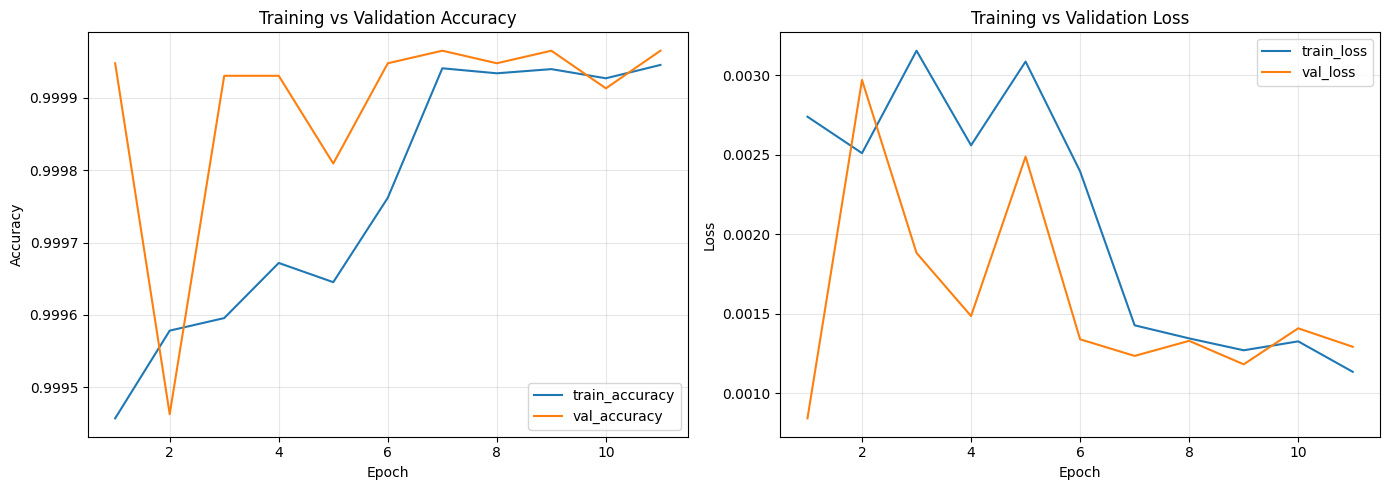

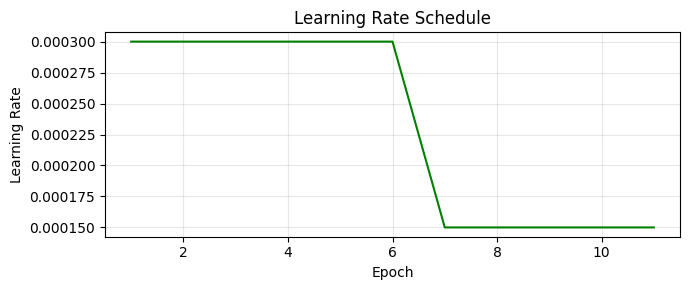

val_loss=0.0012, val_acc=1.0000
              precision    recall  f1-score   support

          你好       1.00      1.00      1.00       375
          學校       1.00      1.00      1.00       376
          同學       1.00      1.00      1.00       367
         屋企人       1.00      1.00      1.00       370
          鐘意       1.00      1.00      1.00       357
         唔鐘意       1.00      1.00      1.00       373
          點解       1.00      1.00      1.00       371
          彩虹       1.00      1.00      1.00       367
          謝謝       1.00      1.00      1.00       352
          等等       1.00      1.00      1.00       371
         對不起       1.00      1.00      1.00       370
          聾人       1.00      1.00      1.00       371
           我       1.00      1.00      1.00       370
          健聽       1.00      1.00      1.00       371
         ⁠手語       1.00      1.00      1.00       371
          現在       1.00      1.00      1.00       370
          高級       1.00      1.00      1.00      

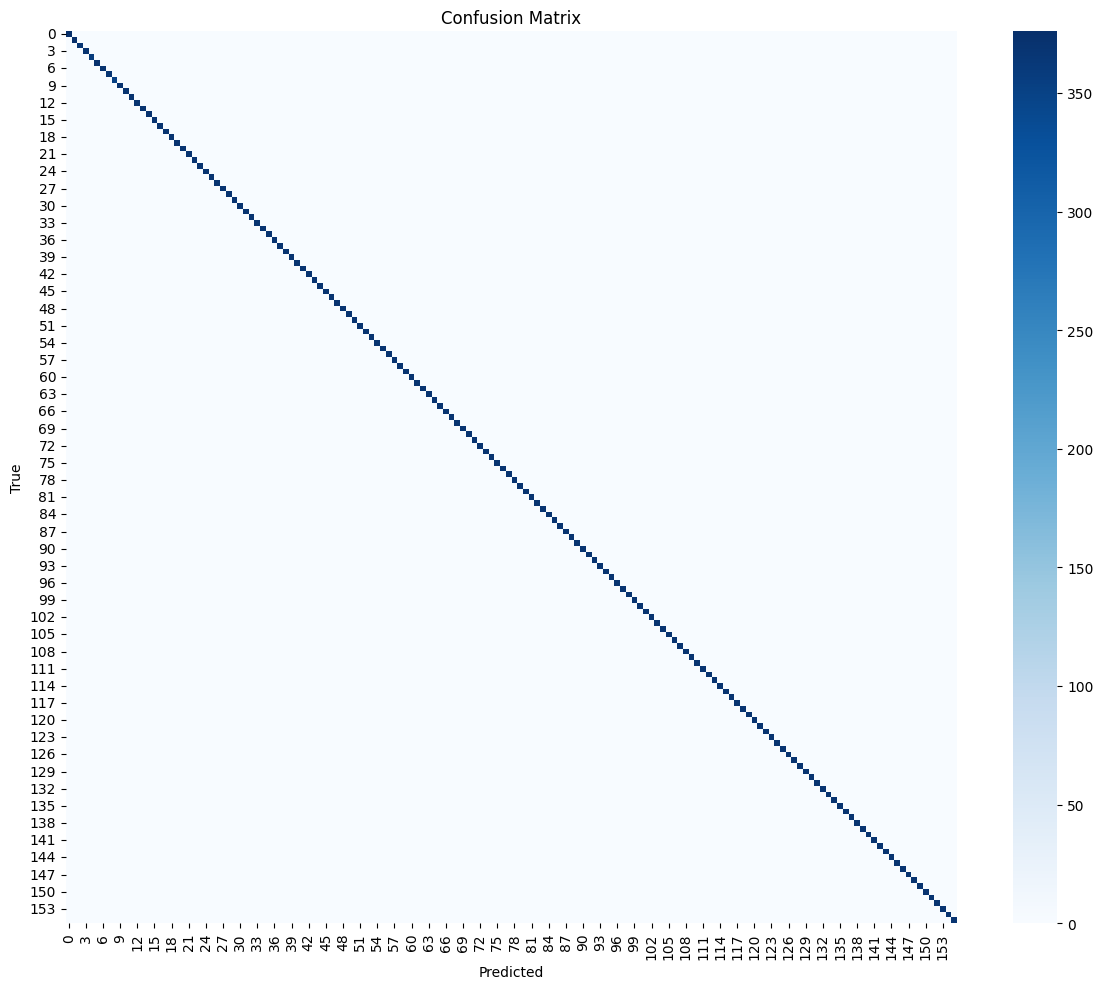


=== 最常混淆的類別對（>2 次）===

Keras model: c:\GitHub\FYP-SignLanguage\cv_hands\model\keypoint_classifier\keypoint_sequence_classifier.keras


INFO:tensorflow:Assets written to: c:\GitHub\FYP-SignLanguage\cv_hands\model\keypoint_classifier\keypoint_sequence_classifier_savedmodel\assets


INFO:tensorflow:Assets written to: c:\GitHub\FYP-SignLanguage\cv_hands\model\keypoint_classifier\keypoint_sequence_classifier_savedmodel\assets


SavedModel: c:\GitHub\FYP-SignLanguage\cv_hands\model\keypoint_classifier\keypoint_sequence_classifier_savedmodel


Exception ignored in: <function Delegate.__del__ at 0x00000134793DA0E0>
Traceback (most recent call last):
  File "c:\GitHub\FYP-SignLanguage\cv_hands\.venv-train310\lib\site-packages\tensorflow\lite\python\interpreter.py", line 117, in __del__
    if self._library is not None:
AttributeError: 'Delegate' object has no attribute '_library'


TFLite: c:\GitHub\FYP-SignLanguage\cv_hands\model\keypoint_classifier\keypoint_sequence_classifier.tflite
Flex delegate unavailable: Could not find module 'libtensorflowlite_flex.dll' (or one of its dependencies). Try using the full path with constructor syntax.

TFLite smoke test:
  Predicted: 132 (右)
  Actual:    132 (右)
  Confidence: 1.0000


In [ ]:
# ── 訓練曲線 ──
if history is None:
    print('No training history (expand warmup only?). Skipping curves.')
else:
    hist = history.history
    epochs_range = range(1, len(hist['accuracy']) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(epochs_range, hist['accuracy'], label='train_accuracy')
    ax1.plot(epochs_range, hist['val_accuracy'], label='val_accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.set_title('Training vs Validation Accuracy')
    ax1.legend()
    ax1.grid(alpha=0.3)

    ax2.plot(epochs_range, hist['loss'], label='train_loss')
    ax2.plot(epochs_range, hist['val_loss'], label='val_loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.set_title('Training vs Validation Loss')
    ax2.legend()
    ax2.grid(alpha=0.3)

    lr_key = 'lr' if 'lr' in hist else ('learning_rate' if 'learning_rate' in hist else None)
    if lr_key:
        fig2, ax3 = plt.subplots(figsize=(7, 3))
        ax3.plot(epochs_range, hist[lr_key], color='green')
        ax3.set_xlabel('Epoch')
        ax3.set_ylabel('Learning Rate')
        ax3.set_title('Learning Rate Schedule')
        ax3.grid(alpha=0.3)
        fig2.tight_layout()

    fig.tight_layout()
    plt.show()

# ── 評估 ──
val_loss, val_acc = model.evaluate(X_test, y_test, verbose=0)
print(f'val_loss={val_loss:.4f}, val_acc={val_acc:.4f}')

y_prob = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_prob, axis=1)
print(classification_report(y_test, y_pred, target_names=labels, zero_division=0))

# ── 混淆矩陣 ──
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

# ── 列出最常混淆的類別對 ──
print('\n=== 最常混淆的類別對（>2 次）===')
for i in range(len(cm)):
    for j in range(len(cm)):
        if i != j and cm[i][j] > 2:
            print(f"  '{labels[i]}' → '{labels[j]}': {cm[i][j]} 次")

# ── 匯出 .keras / SavedModel / TFLite ──
# .keras（checkpoint 期間只存 weights，這裡輸出完整模型）
model.save(str(MODEL_SAVE_PATH))
print(f'\nKeras model: {MODEL_SAVE_PATH}')

# SavedModel
os.makedirs(str(SAVED_MODEL_DIR), exist_ok=True)
model.save(str(SAVED_MODEL_DIR), include_optimizer=False)
print(f'SavedModel: {SAVED_MODEL_DIR}')

# TFLite
converter = tf.lite.TFLiteConverter.from_saved_model(str(SAVED_MODEL_DIR))
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS, tf.lite.OpsSet.SELECT_TF_OPS]
converter._experimental_lower_tensor_list_ops = False
tflite_model = converter.convert()
with open(str(TFLITE_SAVE_PATH), 'wb') as f:
    f.write(tflite_model)
print(f'TFLite: {TFLITE_SAVE_PATH}')

# ── TFLite 推論 Smoke Test ──
from tensorflow.lite.python.interpreter import load_delegate
flex_lib = {
    'Windows': 'libtensorflowlite_flex.dll',
    'Linux': 'libtensorflowlite_flex.so',
    'Darwin': 'libtensorflowlite_flex.dylib'
}.get(platform.system(), 'libtensorflowlite_flex.so')

try:
    delegate = load_delegate(flex_lib)
    interpreter = tf.lite.Interpreter(model_path=str(TFLITE_SAVE_PATH), experimental_delegates=[delegate])
    print('Using flex delegate:', flex_lib)
except Exception as e:
    print('Flex delegate unavailable:', e)
    interpreter = tf.lite.Interpreter(model_path=str(TFLITE_SAVE_PATH))

interpreter.allocate_tensors()
input_detail = interpreter.get_input_details()[0]
output_detail = interpreter.get_output_details()[0]
interpreter.set_tensor(input_detail['index'], X_test[:1].astype(np.float32))
interpreter.invoke()
pred = interpreter.get_tensor(output_detail['index'])
pred_idx = int(np.argmax(pred, axis=1)[0])
true_idx = int(y_test[0])
print(f'\nTFLite smoke test:')
print(f'  Predicted: {pred_idx} ({labels[pred_idx] if pred_idx < len(labels) else "N/A"})')
print(f'  Actual:    {true_idx} ({labels[true_idx] if true_idx < len(labels) else "N/A"})')
print(f'  Confidence: {float(np.max(pred)):.4f}')

## 第 6 格在做什麼？（可選 5-fold 驗證）

這一格定義 `run_stratified_kfold(...)`，不會自動執行。

用途：
- 降低單次 train/test split 的偶然性
- 取得更穩定的平均準確率與標準差

建議：
- 先用 `n_splits=3, epochs=10` 快速測試
- 再跑正式 `n_splits=5, epochs=40` 產出最終結果

In [ ]:
from sklearn.model_selection import StratifiedKFold
import gc

# Optional: 5-fold cross validation (time-consuming)
def run_stratified_kfold(model_type='GRU', n_splits=5, epochs=40, batch_size=32, verbose=1):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_SEED)
    fold_accs = []

    can_stream = 'make_batched_dataset' in globals()

    def _fit_once(m, x_tr, y_tr, x_va, y_va, bs, use_stream):
        if use_stream and can_stream:
            train_ds, train_steps = make_batched_dataset(x_tr, y_tr, bs, shuffle=True, seed=RANDOM_SEED)
            val_ds, val_steps = make_batched_dataset(x_va, y_va, bs, shuffle=False, seed=RANDOM_SEED)
            m.fit(
                train_ds,
                validation_data=val_ds,
                epochs=epochs,
                steps_per_epoch=train_steps,
                validation_steps=val_steps,
                callbacks=fold_callbacks,
                verbose=verbose
            )
        else:
            m.fit(
                x_tr.astype(np.float32),
                y_tr.astype(np.int32),
                validation_data=(x_va.astype(np.float32), y_va.astype(np.int32)),
                epochs=epochs,
                batch_size=bs,
                callbacks=fold_callbacks,
                verbose=verbose
            )

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_dataset, y_dataset), start=1):
        print(f'\n===== Fold {fold}/{n_splits} =====')

        # 每個 fold 先清一次，避免前一 fold 圖/張量殘留
        tf.keras.backend.clear_session()
        gc.collect()

        x_tr, x_va = X_dataset[train_idx], X_dataset[val_idx]
        y_tr, y_va = y_dataset[train_idx], y_dataset[val_idx]
        print('Train shape:', x_tr.shape, 'Val shape:', x_va.shape)

        m = build_model(model_type, SEQUENCE_LENGTH, FEATURES_PER_FRAME, len(labels))
        m.compile(
            optimizer=tf.keras.optimizers.Adam(1e-3),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )

        fold_callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor='val_loss',
                patience=10,
                min_delta=1e-6,
                restore_best_weights=True
            )
        ]

        use_stream = can_stream
        trained = False

        try:
            _fit_once(m, x_tr, y_tr, x_va, y_va, batch_size, use_stream)
            trained = True
        except (tf.errors.InternalError, tf.errors.ResourceExhaustedError) as e:
            print(f'GPU failed on fold {fold}: {e}')

            retry_bs_list = [max(8, batch_size // 2), 8]
            retry_bs_list = list(dict.fromkeys(retry_bs_list))

            for retry_bs in retry_bs_list:
                try:
                    print(f'Retrying on GPU with batch_size={retry_bs}, stream={use_stream} ...')
                    tf.keras.backend.clear_session()
                    gc.collect()

                    m = build_model(model_type, SEQUENCE_LENGTH, FEATURES_PER_FRAME, len(labels))
                    m.compile(
                        optimizer=tf.keras.optimizers.Adam(1e-3),
                        loss='sparse_categorical_crossentropy',
                        metrics=['accuracy']
                    )

                    _fit_once(m, x_tr, y_tr, x_va, y_va, retry_bs, use_stream)
                    trained = True
                    print(f'GPU retry succeeded on fold {fold} with batch_size={retry_bs}.')
                    break
                except (tf.errors.InternalError, tf.errors.ResourceExhaustedError) as retry_e:
                    print(f'GPU retry failed at batch_size={retry_bs}: {retry_e}')

            if not trained:
                print('Retrying this fold on CPU with smaller batch size...')
                tf.keras.backend.clear_session()
                gc.collect()

                cpu_bs = max(8, batch_size // 2)
                m = build_model(model_type, SEQUENCE_LENGTH, FEATURES_PER_FRAME, len(labels))
                m.compile(
                    optimizer=tf.keras.optimizers.Adam(1e-3),
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy']
                )

                with tf.device('/CPU:0'):
                    _fit_once(m, x_tr, y_tr, x_va, y_va, cpu_bs, use_stream=False)

        _, acc = m.evaluate(x_va.astype(np.float32), y_va.astype(np.int32), verbose=0)
        fold_accs.append(acc)
        print(f'Fold {fold} accuracy: {acc:.4f}')

        # fold 結束立即釋放
        del m, x_tr, x_va, y_tr, y_va
        tf.keras.backend.clear_session()
        gc.collect()

    print(f'\nMean ± Std = {np.mean(fold_accs):.4f} ± {np.std(fold_accs):.4f}')
    return fold_accs

# 使用方式（建議先小規模測試）:
fold_accs = run_stratified_kfold(model_type=MODEL_TYPE, n_splits=5, epochs=40, batch_size=32, verbose=1)


===== Fold 1/5 =====
Train shape: (184652, 25, 80) Val shape: (46164, 25, 80)
Epoch 1/40
5771/5771 [==============================] - 86s 14ms/step - loss: 0.3744 - accuracy: 0.9184 - val_loss: 0.0921 - val_accuracy: 0.9941
Epoch 2/40
5771/5771 [==============================] - 82s 14ms/step - loss: 0.1305 - accuracy: 0.9840 - val_loss: 0.0913 - val_accuracy: 0.9930
Epoch 3/40
5771/5771 [==============================] - 81s 14ms/step - loss: 0.1178 - accuracy: 0.9872 - val_loss: 0.0788 - val_accuracy: 0.9964
Epoch 4/40
5771/5771 [==============================] - 75s 13ms/step - loss: 0.1051 - accuracy: 0.9897 - val_loss: 0.1028 - val_accuracy: 0.9907
Epoch 5/40
5771/5771 [==============================] - 75s 13ms/step - loss: 0.0911 - accuracy: 0.9920 - val_loss: 0.0681 - val_accuracy: 0.9969
Epoch 6/40
5771/5771 [==============================] - 75s 13ms/step - loss: 0.0834 - accuracy: 0.9927 - val_loss: 0.0579 - val_accuracy: 0.9984
Epoch 7/40
5771/5771 [=======================

## 第 7 格在做什麼？（五維度壓力測試：找出「數據漂亮、實測翻車」核心原因）

這格會把你指定的 5 個檢查維度變成可量化測試，並輸出每個維度的敏感度分數：

1. 座標系統魯棒性：縮放/平移擾動，檢查是否記住絕對座標。
2. 關鍵點品質：模擬關鍵點抖動、掉點與低品質輸入，檢查抗噪能力。
3. 特徵純淨度：模擬不同身形比例，檢查是否過度依賴特定人體比例。
4. 時間序列穩定性：快慢速、前導雜訊（揮手）擾動，檢查時序泛化。
5. 連續識別切割：休息狀態誤觸發與連續 A/B/C 動作的切分穩定度。

執行方式：
- 先完成第 2~5 格（確保 `model`, `X_test`, `y_test` 已存在）
- 再執行下一格，會輸出各維度 drop 與核心原因排名

In [ ]:
# 五維度壓力測試（可量化）
import numpy as np
from collections import defaultdict

def _assert_ready():
    required = ['model', 'X_test', 'y_test', 'SEQUENCE_LENGTH', 'FEATURES_PER_FRAME']
    missing = [k for k in required if k not in globals()]
    if missing:
        raise RuntimeError(f'Missing globals: {missing}. 請先執行第 2~5 格。')


def _predict_acc(model_obj, X, y):
    y_prob = model_obj.predict(X.astype(np.float32), verbose=0)
    y_pred = np.argmax(y_prob, axis=1).astype(np.int32)
    return float((y_pred == y.astype(np.int32)).mean()), y_pred, y_prob


def _reshape_points(X):
    # (N, T, F) -> (N, T, P, 2), 假設每個關鍵點是 (x, y)
    N, T, F = X.shape
    if F % 2 != 0:
        raise ValueError(f'FEATURES_PER_FRAME={F} 不是偶數，無法拆成 (x,y) 關鍵點。')
    return X.reshape(N, T, F // 2, 2)


def _flatten_points(P):
    # (N, T, P, 2) -> (N, T, F)
    N, T, K, C = P.shape
    return P.reshape(N, T, K * C).astype(np.float32)


def _translate(X, dx=0.0, dy=0.0):
    P = _reshape_points(X).copy()
    P[..., 0] += np.float32(dx)
    P[..., 1] += np.float32(dy)
    return _flatten_points(P)


def _scale_about_anchor(X, scale=1.0, anchor_idx=0):
    P = _reshape_points(X).copy()
    anchor = P[:, :, anchor_idx:anchor_idx + 1, :]
    P = (P - anchor) * np.float32(scale) + anchor
    return _flatten_points(P)


def _morph_body_ratio(X, sx=1.0, sy=1.0, anchor_idx=0):
    P = _reshape_points(X).copy()
    anchor = P[:, :, anchor_idx:anchor_idx + 1, :]
    P_rel = P - anchor
    P_rel[..., 0] *= np.float32(sx)
    P_rel[..., 1] *= np.float32(sy)
    P = P_rel + anchor
    return _flatten_points(P)


def _jitter_noise(X, sigma=0.01, seed=42):
    rng = np.random.default_rng(seed)
    noise = rng.normal(0.0, sigma, size=X.shape).astype(np.float32)
    return (X + noise).astype(np.float32)


def _drop_keypoints(X, drop_ratio=0.1, seed=42):
    rng = np.random.default_rng(seed)
    P = _reshape_points(X).copy()
    mask = rng.random(size=P.shape[:-1]) < drop_ratio
    P[mask, :] = 0.0
    return _flatten_points(P)


def _ema_smooth(X, alpha=0.55):
    Y = X.copy().astype(np.float32)
    for t in range(1, Y.shape[1]):
        Y[:, t, :] = alpha * Y[:, t, :] + (1.0 - alpha) * Y[:, t - 1, :]
    return Y


def _time_resample_one(seq, new_len):
    # seq: (T, F)
    old_len = seq.shape[0]
    if old_len == new_len:
        return seq.copy()
    old_idx = np.linspace(0, old_len - 1, old_len, dtype=np.float32)
    new_idx = np.linspace(0, old_len - 1, new_len, dtype=np.float32)
    out = np.empty((new_len, seq.shape[1]), dtype=np.float32)
    for f in range(seq.shape[1]):
        out[:, f] = np.interp(new_idx, old_idx, seq[:, f])
    return out


def _speed_change_fixed_len(X, speed=1.0):
    # speed > 1: 動作變快；speed < 1: 動作變慢
    T = X.shape[1]
    target = max(3, int(round(T / speed)))
    Y = np.empty_like(X, dtype=np.float32)
    for i in range(X.shape[0]):
        warped = _time_resample_one(X[i], target)
        fixed = _time_resample_one(warped, T)
        Y[i] = fixed
    return Y


def _prepend_leading_motion(X, ratio=0.25, seed=42):
    # 前導隨機揮手: 前 ratio 幀替換為隨機序列片段
    rng = np.random.default_rng(seed)
    Y = X.copy().astype(np.float32)
    T = Y.shape[1]
    k = max(1, int(T * ratio))
    src_ids = rng.integers(0, X.shape[0], size=X.shape[0])
    for i, sid in enumerate(src_ids):
        Y[i, :k, :] = X[sid, :k, :]
    return Y


def _none_false_trigger_rate(model_obj, X_ref, threshold=0.75, n=256, seed=42):
    # 以接近靜止的窗口模擬 None/休息狀態
    rng = np.random.default_rng(seed)
    n = min(n, len(X_ref))
    idx = rng.choice(len(X_ref), size=n, replace=False)
    base = X_ref[idx].copy().astype(np.float32)
    rest = np.zeros_like(base, dtype=np.float32)
    tiny = rng.normal(0.0, 0.003, size=rest.shape).astype(np.float32)
    rest = rest + tiny
    prob = model_obj.predict(rest, verbose=0)
    max_conf = np.max(prob, axis=1)
    trigger = (max_conf >= threshold).mean()
    return float(trigger), float(max_conf.mean())


def _continuous_abc_switch_score(model_obj, X_ref, y_ref, stride=5, seed=42):
    # 以真實樣本拼接 A->B->C，滑窗檢查切割是否容易亂碼
    rng = np.random.default_rng(seed)
    classes = np.unique(y_ref)
    if len(classes) < 3:
        return np.nan, {'reason': 'classes < 3'}

    picked = rng.choice(classes, size=3, replace=False)
    seqs = []
    for c in picked:
        candidates = np.where(y_ref == c)[0]
        sid = int(rng.choice(candidates))
        seqs.append(X_ref[sid])

    stream = np.concatenate(seqs, axis=0)  # (3T, F)
    T = X_ref.shape[1]
    windows = []
    for s in range(0, stream.shape[0] - T + 1, stride):
        windows.append(stream[s:s + T])
    windows = np.stack(windows, axis=0).astype(np.float32)

    prob = model_obj.predict(windows, verbose=0)
    pred = np.argmax(prob, axis=1)
    changes = int(np.sum(pred[1:] != pred[:-1]))
    # 理想狀態 A->B->C 應該約有 2 次主要切換；過多通常代表切割亂跳
    over_switch = max(0, changes - 2)
    return float(over_switch), {
        'picked_classes': picked.tolist(),
        'window_count': int(len(windows)),
        'switch_count': int(changes),
    }


def run_five_dimension_stress_test(
    n_samples=512,
    none_threshold=0.75,
    seed=42,
):
    _assert_ready()
    rng = np.random.default_rng(seed)

    n = min(n_samples, len(X_test))
    idx = rng.choice(len(X_test), size=n, replace=False)
    Xb = X_test[idx].astype(np.float32)
    yb = y_test[idx].astype(np.int32)

    base_acc, _, _ = _predict_acc(model, Xb, yb)
    print(f'[Baseline] acc={base_acc:.4f} on n={n}')

    rows = []

    def add_row(dimension, case_name, acc):
        drop = base_acc - acc
        rows.append({
            'dimension': dimension,
            'case': case_name,
            'acc': float(acc),
            'drop': float(drop),
        })

    # 1) 座標系統魯棒性
    for case_name, Xt in [
        ('scale_in_1.35x', _scale_about_anchor(Xb, scale=1.35, anchor_idx=0)),
        ('scale_out_0.65x', _scale_about_anchor(Xb, scale=0.65, anchor_idx=0)),
        ('translate_left_top', _translate(Xb, dx=-0.25, dy=-0.25)),
        ('translate_right_bottom', _translate(Xb, dx=0.25, dy=0.25)),
    ]:
        acc, _, _ = _predict_acc(model, Xt, yb)
        add_row('1.coordinate_robustness', case_name, acc)

    # 2) 關鍵點品質
    noisy = _jitter_noise(Xb, sigma=0.02, seed=seed)
    droppt = _drop_keypoints(Xb, drop_ratio=0.12, seed=seed)
    noisy_smooth = _ema_smooth(noisy, alpha=0.55)

    for case_name, Xt in [
        ('keypoint_jitter_sigma0.02', noisy),
        ('keypoint_dropout_12pct', droppt),
        ('jitter_then_ema_smooth', noisy_smooth),
    ]:
        acc, _, _ = _predict_acc(model, Xt, yb)
        add_row('2.keypoint_quality', case_name, acc)

    # 3) 特徵純淨度（身形比例擾動）
    for case_name, Xt in [
        ('morph_x1.25_y0.85', _morph_body_ratio(Xb, sx=1.25, sy=0.85, anchor_idx=0)),
        ('morph_x0.85_y1.25', _morph_body_ratio(Xb, sx=0.85, sy=1.25, anchor_idx=0)),
    ]:
        acc, _, _ = _predict_acc(model, Xt, yb)
        add_row('3.feature_purity', case_name, acc)

    # 4) 時間序列穩定性
    for case_name, Xt in [
        ('speed_2x_faster', _speed_change_fixed_len(Xb, speed=2.0)),
        ('speed_0.5x_slower', _speed_change_fixed_len(Xb, speed=0.5)),
        ('leading_motion_25pct', _prepend_leading_motion(Xb, ratio=0.25, seed=seed)),
    ]:
        acc, _, _ = _predict_acc(model, Xt, yb)
        add_row('4.temporal_stability', case_name, acc)

    # 5) 連續識別切割
    false_trigger_rate, rest_mean_conf = _none_false_trigger_rate(
        model, X_test, threshold=none_threshold, n=min(256, len(X_test)), seed=seed
    )
    # 將誤觸發率映射成「等效準確率」以便和其他維度比較（越高越好）
    rest_equiv_acc = 1.0 - false_trigger_rate
    add_row('5.segmentation', f'rest_false_trigger@{none_threshold:.2f}', rest_equiv_acc)

    over_switch, seg_detail = _continuous_abc_switch_score(model, X_test, y_test, stride=5, seed=seed)
    if np.isnan(over_switch):
        seg_equiv_acc = np.nan
    else:
        # over_switch 越多越差；使用指數衰減轉成 0~1
        seg_equiv_acc = float(np.exp(-0.35 * over_switch))
        add_row('5.segmentation', 'continuous_abc_over_switch', seg_equiv_acc)

    # 匯總
    by_dim = defaultdict(list)
    for r in rows:
        if not np.isnan(r['drop']):
            by_dim[r['dimension']].append(r['drop'])

    dim_score = []
    for d, drops in by_dim.items():
        dim_score.append((d, float(np.mean(drops)), float(np.max(drops))))
    dim_score = sorted(dim_score, key=lambda x: x[1], reverse=True)

    print('\n=== Case Results ===')
    for r in sorted(rows, key=lambda x: x['drop'], reverse=True):
        print(f"{r['dimension']:24s} | {r['case']:30s} | acc={r['acc']:.4f} | drop={r['drop']:.4f}")

    print('\n=== Dimension Ranking (mean drop / max drop) ===')
    for d, mean_drop, max_drop in dim_score:
        print(f'{d:24s} | mean_drop={mean_drop:.4f} | max_drop={max_drop:.4f}')

    print('\n=== Segmentation Extra Metrics ===')
    print(f'rest_false_trigger_rate={false_trigger_rate:.4f} (threshold={none_threshold:.2f}, mean_conf={rest_mean_conf:.4f})')
    print(f'continuous_abc_detail={seg_detail}')

    # 自動判讀
    print('\n=== Core Cause Diagnosis ===')
    if len(dim_score) == 0:
        print('無法判讀（沒有有效測試結果）。')
        return rows, dim_score

    top_dim, top_mean, top_max = dim_score[0]
    print(f'最可能核心瓶頸: {top_dim} (mean_drop={top_mean:.4f}, max_drop={top_max:.4f})')

    if top_dim.startswith('1.') and top_mean > 0.08:
        print('- 模型高度依賴絕對座標。建議改為「以手腕/胸口為原點」相對座標 + 尺度正規化。')
    if top_dim.startswith('2.') and top_mean > 0.08:
        print('- 關鍵點品質是主瓶頸。建議上游加入平滑濾波(EMA/Kalman)與關鍵點可信度門檻。')
    if top_dim.startswith('3.') and top_mean > 0.08:
        print('- 模型疑似學到體型捷徑。建議擴充不同體型資料，或改用關節角度特徵。')
    if top_dim.startswith('4.') and top_mean > 0.08:
        print('- 時序泛化不足。建議強化 time-warp augmentation，並在串流推論中加入起訖偵測與狀態重置。')
    if top_dim.startswith('5.') and top_mean > 0.08:
        print('- 切割問題明顯。建議新增 None/背景類與更穩定的滑動窗口/門檻策略。')

    if false_trigger_rate > 0.30:
        print('- 休息狀態誤觸發偏高：強烈建議加入 None 類樣本訓練。')
    if not np.isnan(over_switch) and over_switch > 4:
        print('- 連續動作切割過度抖動：請加上時間平滑與最短持續幀數限制。')

    return rows, dim_score


# 執行測試
stress_rows, stress_ranking = run_five_dimension_stress_test(
    n_samples=512,
    none_threshold=0.75,
    seed=42,
)
print('\n完成：請查看 Dimension Ranking 與 Core Cause Diagnosis。')

[Baseline] acc=1.0000 on n=512

=== Case Results ===
5.segmentation           | rest_false_trigger@0.75        | acc=0.0000 | drop=1.0000
5.segmentation           | continuous_abc_over_switch     | acc=0.3499 | drop=0.6501
1.coordinate_robustness  | scale_out_0.65x                | acc=0.5625 | drop=0.4375
4.temporal_stability     | speed_2x_faster                | acc=0.7695 | drop=0.2305
4.temporal_stability     | leading_motion_25pct           | acc=0.8184 | drop=0.1816
1.coordinate_robustness  | translate_left_top             | acc=0.8965 | drop=0.1035
1.coordinate_robustness  | scale_in_1.35x                 | acc=0.9043 | drop=0.0957
3.feature_purity         | morph_x0.85_y1.25              | acc=0.9180 | drop=0.0820
2.keypoint_quality       | jitter_then_ema_smooth         | acc=0.9258 | drop=0.0742
1.coordinate_robustness  | translate_right_bottom         | acc=0.9316 | drop=0.0684
2.keypoint_quality       | keypoint_dropout_12pct         | acc=0.9727 | drop=0.0273
3.feature_pu